## Autonomous (oscillatory) FHN identification with SINDy

In [25]:
import numpy as np
import pysindy as ps
import matplotlib.pyplot as plt
import sklearn
import scienceplots
from sklearn.metrics import mean_squared_error
from model_fhn import solve_fhn
plt.style.use(['science'])
# plt.rcParams.update({'font.size': 14})

### Usando derivadas conhecidas

In [26]:
# data = np.loadtxt('output_fhn.txt')

# t_data  = data[:, 0]
# v_data  = data[:, 1]
# w_data  = data[:, 2]
# # dx_data = data[:, 3:5]

# X = np.zeros((len(t_data), 2))
# X[:, 0] = v_data
# X[:, 1] = w_data

# dt = t_data[1] - t_data[0]

In [27]:
n = 2
dt = 0.01
tf = 300.0
x0 = (0.0, 0.0) 

data = solve_fhn(x0, t_final=tf, dt=dt)

t_data  = data[0,:]
v_data  = data[1,:]
w_data  = data[2,:]

X = np.zeros((len(t_data), 2))
X[:, 0] = v_data
X[:, 1] = w_data
dt = t_data[1] - t_data[0]

In [28]:
t_data, X, dt

(array([0.0000e+00, 1.0000e-02, 2.0000e-02, ..., 2.9998e+02, 2.9999e+02,
        3.0000e+02]),
 array([[0.00000000e+00, 0.00000000e+00],
        [5.02347489e-03, 3.20958238e-04],
        [1.00941997e-02, 6.43845163e-04],
        ...,
        [1.71516055e+00, 5.76241659e-01],
        [1.71473096e+00, 5.77086171e-01],
        [1.71430127e+00, 5.77930275e-01]]),
 0.01)

In [29]:
print('SR3, STLSQ and LASSO regression solvers - without normalization')

# =============================================================================
# SETUP — Threshold grid & result containers
# =============================================================================

nth = 21
thr = np.linspace(0.0, 1, nth)
lib3 = ps.PolynomialLibrary(degree=3)

# --- Model lists ---
sr3_models   = []
stlsq_models = []
lasso_models = []

# --- Metrics ---
sr3_mse   = np.zeros(nth)
sr3_r2c   = np.zeros(nth)
stlsq_mse = np.zeros(nth)
stlsq_r2c = np.zeros(nth)
lasso_mse = np.zeros(nth)
lasso_r2c = np.zeros(nth)

# =============================================================================
# MAIN LOOP — Fit models for each threshold value
# =============================================================================

for i, th in enumerate(thr):
    print(f'lambda = {th}')

    # --- Optimizers ---
    opt_sr3   = ps.SR3(threshold=th, normalize_columns=False)
    opt_stlsq = ps.STLSQ(threshold=th, normalize_columns=False)
    opt_lasso = sklearn.linear_model.Lasso(alpha=th, max_iter=10000, fit_intercept=False)

    # --- Common SINDy kwargs ---
    sindy_kwargs = dict(
        differentiation_method=ps.SINDyDerivative(),
        feature_library=lib3,
        feature_names=["v", "w"],
    )

    # --- Fit SR3 ---
    model_sr3 = ps.SINDy(optimizer=opt_sr3, **sindy_kwargs)
    model_sr3.fit(X, t=dt)
    model_sr3.print()

    # --- Fit STLSQ ---
    model_stlsq = ps.SINDy(optimizer=opt_stlsq, **sindy_kwargs)
    model_stlsq.fit(X, t=dt)
    model_stlsq.print()

    # --- Fit LASSO ---
    model_lasso = ps.SINDy(optimizer=opt_lasso, **sindy_kwargs)
    model_lasso.fit(X, t=dt)
    model_lasso.print()

    # --- Store models & scores ---
    for model, models_list, mse_arr, r2_arr in [
        (model_sr3,   sr3_models,   sr3_mse,   sr3_r2c),
        (model_stlsq, stlsq_models, stlsq_mse, stlsq_r2c),
        (model_lasso, lasso_models, lasso_mse, lasso_r2c),
    ]:
        models_list.append(model)
        mse_arr[i] = model.score(X, t=dt, metric=mean_squared_error)
        r2_arr[i]  = model.score(X, t=dt)

SR3, STLSQ and LASSO regression solvers - without normalization
lambda = 0.0
(v)' = 0.500 1 + 1.000 v + -1.000 w + -0.333 v^3
(w)' = 0.032 1 + 0.040 v + -0.028 w
(v)' = 0.500 1 + 1.000 v + -1.000 w + -0.333 v^3
(w)' = 0.032 1 + 0.040 v + -0.028 w


/home/rocha/anaconda3/lib/python3.11/site-packages/sklearn/base.py:1389: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
/home/rocha/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:695: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(


(v)' = 0.500 1 + 1.000 v + -1.000 w + -0.333 v^3
(w)' = 0.032 1 + 0.040 v + -0.028 w
lambda = 0.05
(v)' = 0.500 1 + 1.000 v + -1.000 w + -0.333 v^3
(w)' = 0.000


/home/rocha/anaconda3/lib/python3.11/site-packages/pysindy/optimizers/stlsq.py:201: UserWarning: Sparsity parameter is too big (0.05) and eliminated all coefficients
  warnings.warn(


(v)' = 0.500 1 + 1.000 v + -1.000 w + -0.333 v^3
(w)' = 0.000
(v)' = 0.029 v^2 + -0.179 w^3
(w)' = 0.012 v^3
lambda = 0.1
(v)' = 0.500 1 + 1.000 v + -1.000 w + -0.333 v^3
(w)' = 0.000


...

(v)' = 0.000
(w)' = 0.000
(v)' = 0.000
(w)' = 0.000
lambda = 0.9500000000000001
(v)' = 0.002 v + -0.154 w
(w)' = 0.000


/home/rocha/anaconda3/lib/python3.11/site-packages/pysindy/optimizers/stlsq.py:201: UserWarning: Sparsity parameter is too big (0.9500000000000001) and eliminated all coefficients
  warnings.warn(
/home/rocha/anaconda3/lib/python3.11/site-packages/pysindy/optimizers/stlsq.py:191: UserWarning: Sparsity parameter is too big (0.9500000000000001) and eliminated all coefficients
  warnings.warn(


(v)' = 0.000
(w)' = 0.000
(v)' = 0.000
(w)' = 0.000
lambda = 1.0
(v)' = 0.000
(w)' = 0.000


/home/rocha/anaconda3/lib/python3.11/site-packages/pysindy/optimizers/stlsq.py:191: UserWarning: Sparsity parameter is too big (1.0) and eliminated all coefficients
  warnings.warn(


(v)' = 0.000
(w)' = 0.000
(v)' = 0.000
(w)' = 0.000


### Plot metrics

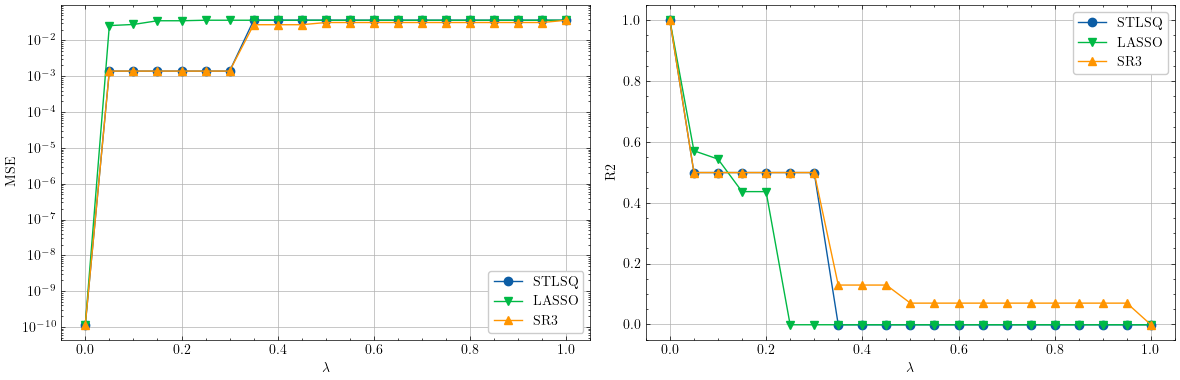

In [30]:
plt.style.use(['science'])
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.grid(True)
plt.semilogy(thr, stlsq_mse, '-o', label='STLSQ')
plt.semilogy(thr, lasso_mse, '-v', label='LASSO')
plt.semilogy(thr, sr3_mse, '-^', label='SR3')
plt.xlabel(r'$\lambda$')
plt.ylabel('MSE')
plt.legend(loc='best', frameon=True, framealpha=1.0)

plt.subplot(1, 2, 2)
plt.grid(True)
plt.plot(thr[:], stlsq_r2c[:], '-o', label='STLSQ')
plt.plot(thr[:], lasso_r2c[:], '-v', label='LASSO')
plt.plot(thr[:], sr3_r2c[:], '-^', label='SR3')
plt.xlabel(r'$\lambda$')
plt.ylabel('R2')
plt.legend(loc='best', frameon=True, framealpha=1.0)

plt.tight_layout()
plt.savefig('fig_sindy_fhn.pdf',dpi=300)
plt.savefig('fig_sindy_fhn.png',dpi=300)
plt.show()

In [31]:
np.savetxt("metrics_stlsq.txt", np.transpose([thr,stlsq_mse,stlsq_r2c]))
np.savetxt("metrics_lasso.txt", np.transpose([thr,lasso_mse,lasso_r2c]))
np.savetxt("metrics_sr3.txt", np.transpose([thr,sr3_mse,sr3_r2c]))

In [32]:
print('Refined search - SR3, STLSQ and LASSO regression solvers - without normalization')

# =============================================================================
# SETUP — Refined threshold grid & result containers
# =============================================================================

nth = 21
thr = np.linspace(0.0, 0.1, nth)   # narrowed range from coarse search
lib3 = ps.PolynomialLibrary(degree=3)

# --- Model lists ---
sr3_models_ref   = []
stlsq_models_ref = []
lasso_models_ref = []

# --- Metrics ---
sr3_mse_ref   = np.zeros(nth)
sr3_r2c_ref   = np.zeros(nth)
stlsq_mse_ref = np.zeros(nth)
stlsq_r2c_ref = np.zeros(nth)
lasso_mse_ref = np.zeros(nth)
lasso_r2c_ref = np.zeros(nth)


# =============================================================================
# MAIN LOOP — Fit models for each threshold value
# =============================================================================

for i, th in enumerate(thr):
    print(f'lambda = {th}')

    # --- Optimizers ---
    opt_sr3   = ps.SR3(threshold=th, normalize_columns=False)
    opt_stlsq = ps.STLSQ(threshold=th, normalize_columns=False)
    opt_lasso = sklearn.linear_model.Lasso(alpha=th, max_iter=10000, fit_intercept=False)

    # --- Common SINDy kwargs ---
    sindy_kwargs = dict(
        differentiation_method=ps.SINDyDerivative(),
        feature_library=lib3,
        feature_names=["v", "w"],
    )

    # --- Fit SR3 ---
    model_sr3 = ps.SINDy(optimizer=opt_sr3, **sindy_kwargs)
    model_sr3.fit(X, t=dt)
    model_sr3.print()

    # --- Fit STLSQ ---
    model_stlsq = ps.SINDy(optimizer=opt_stlsq, **sindy_kwargs)
    model_stlsq.fit(X, t=dt)
    model_stlsq.print()

    # --- Fit LASSO ---
    model_lasso = ps.SINDy(optimizer=opt_lasso, **sindy_kwargs)
    model_lasso.fit(X, t=dt)
    model_lasso.print()

    # --- Store models & scores ---
    for model, models_list, mse_arr, r2_arr in [
        (model_sr3,   sr3_models_ref,   sr3_mse_ref,   sr3_r2c_ref),
        (model_stlsq, stlsq_models_ref, stlsq_mse_ref, stlsq_r2c_ref),
        (model_lasso, lasso_models_ref, lasso_mse_ref, lasso_r2c_ref),
    ]:
        models_list.append(model)
        mse_arr[i] = model.score(X, t=dt, metric=mean_squared_error)
        r2_arr[i]  = model.score(X, t=dt)

Refined search - SR3, STLSQ and LASSO regression solvers - without normalization
lambda = 0.0
(v)' = 0.500 1 + 1.000 v + -1.000 w + -0.333 v^3
(w)' = 0.032 1 + 0.040 v + -0.028 w
(v)' = 0.500 1 + 1.000 v + -1.000 w + -0.333 v^3
(w)' = 0.032 1 + 0.040 v + -0.028 w


/home/rocha/anaconda3/lib/python3.11/site-packages/sklearn/base.py:1389: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
/home/rocha/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:695: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(


(v)' = 0.500 1 + 1.000 v + -1.000 w + -0.333 v^3
(w)' = 0.032 1 + 0.040 v + -0.028 w
lambda = 0.005
(v)' = 0.500 1 + 1.000 v + -1.000 w + -0.333 v^3
(w)' = 0.032 1 + 0.040 v + -0.028 w
(v)' = 0.500 1 + 1.000 v + -1.000 w + -0.333 v^3
(w)' = 0.032 1 + 0.040 v + -0.028 w
(v)' = 0.500 1 + 1.000 v + -1.000 w + -0.333 v^3
(w)' = 0.007 v^2 + 0.014 v^3
lambda = 0.01
(v)' = 0.500 1 + 1.000 v + -1.000 w + -0.333 v^3
(w)' = 0.032 1 + 0.040 v + -0.028 w
(v)' = 0.500 1 + 1.000 v + -1.000 w + -0.333 v^3
(w)' = 0.032 1 + 0.040 v + -0.028 w
(v)' = 0.500 1 + 1.000 v + -1.000 w + -0.333 v^3
(w)' = 0.007 v^2 + 0.014 v^3
lambda = 0.015
(v)' = 0.500 1 + 1.000 v + -1.000 w + -0.333 v^3
(w)' = 0.032 1 + 0.040 v + -0.028 w
(v)' = 0.500 1 + 1.000 v + -1.000 w + -0.333 v^3
(w)' = 0.032 1 + 0.040 v + -0.028 w
(v)' = 0.500 1 + 1.000 v + -1.000 w + -0.333 v^3
(w)' = 0.007 v^2 + 0.014 v^3
lambda = 0.02
(v)' = 0.500 1 + 1.000 v + -1.000 w + -0.333 v^3
(w)' = 0.032 1 + 0.040 v + -0.028 w
(v)' = 0.500 1 + 1.000 v + -

/home/rocha/anaconda3/lib/python3.11/site-packages/pysindy/optimizers/stlsq.py:201: UserWarning: Sparsity parameter is too big (0.035) and eliminated all coefficients
  warnings.warn(


(v)' = 0.500 1 + 1.000 v + -1.000 w + -0.333 v^3
(w)' = 0.000
(v)' = 0.029 v^2 + -0.179 w^3
(w)' = 0.012 v^3
lambda = 0.04
(v)' = 0.500 1 + 1.000 v + -1.000 w + -0.333 v^3
(w)' = 0.000


...

(v)' = 0.500 1 + 1.000 v + -1.000 w + -0.333 v^3
(w)' = 0.000
(v)' = -0.144 w^3
(w)' = 0.012 v^3
lambda = 0.095
(v)' = 0.500 1 + 1.000 v + -1.000 w + -0.333 v^3
(w)' = 0.000


/home/rocha/anaconda3/lib/python3.11/site-packages/pysindy/optimizers/stlsq.py:201: UserWarning: Sparsity parameter is too big (0.095) and eliminated all coefficients
  warnings.warn(


(v)' = 0.500 1 + 1.000 v + -1.000 w + -0.333 v^3
(w)' = 0.000
(v)' = -0.144 w^3
(w)' = 0.012 v^3
lambda = 0.1
(v)' = 0.500 1 + 1.000 v + -1.000 w + -0.333 v^3
(w)' = 0.000


/home/rocha/anaconda3/lib/python3.11/site-packages/pysindy/optimizers/stlsq.py:201: UserWarning: Sparsity parameter is too big (0.1) and eliminated all coefficients
  warnings.warn(


(v)' = 0.500 1 + 1.000 v + -1.000 w + -0.333 v^3
(w)' = 0.000
(v)' = -0.144 w^3
(w)' = 0.012 v^3


### Figure 3 from paper

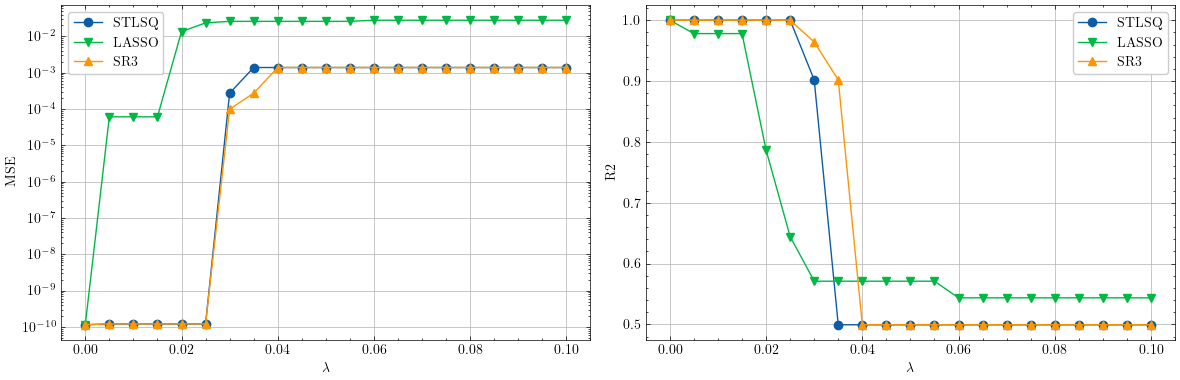

In [33]:
plt.style.use(['science'])
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.grid(True)
plt.semilogy(thr, stlsq_mse_ref, '-o', label='STLSQ')
plt.semilogy(thr, lasso_mse_ref, '-v', label='LASSO')
plt.semilogy(thr, sr3_mse_ref, '-^', label='SR3')
plt.xlabel(r'$\lambda$')
plt.ylabel('MSE')
plt.legend(loc='best', frameon=True, framealpha=1.0)

plt.subplot(1, 2, 2)
plt.grid(True)
plt.plot(thr[:], stlsq_r2c_ref[:], '-o', label='STLSQ')
plt.plot(thr[:], lasso_r2c_ref[:], '-v', label='LASSO')
plt.plot(thr[:], sr3_r2c_ref[:], '-^', label='SR3')
plt.xlabel(r'$\lambda$')
plt.ylabel('R2')
plt.legend(loc='best', frameon=True, framealpha=1.0)

plt.tight_layout()
plt.savefig('fig_sindy_fhn_zoom.pdf',dpi=300)
plt.savefig('fig_sindy_fhn_zoom.png',dpi=300)
plt.show()

In [34]:
np.savetxt("metrics_stlsq_ref.txt", np.transpose([thr,stlsq_mse_ref,stlsq_r2c_ref]))
np.savetxt("metrics_lasso_ref.txt", np.transpose([thr,lasso_mse_ref,lasso_r2c_ref]))
np.savetxt("metrics_sr3_ref.txt", np.transpose([thr,sr3_mse_ref,sr3_r2c_ref]))

### Using normalization of data

In [35]:
print('SR3, STLSQ and SSR regression solvers - with normalization')

# =============================================================================
# SETUP — Threshold grid & result containers
# =============================================================================

nth = 11
thr = np.linspace(0.0, 1, nth)
lib3 = ps.PolynomialLibrary(degree=3)

# --- Model lists ---
sr3_models_norm   = []
stlsq_models_norm = []
ssr_models_norm   = []

# --- Metrics ---
sr3_mse_norm   = np.zeros(nth)
sr3_r2c_norm   = np.zeros(nth)
stlsq_mse_norm = np.zeros(nth)
stlsq_r2c_norm = np.zeros(nth)
ssr_mse_norm   = np.zeros(nth)
ssr_r2c_norm   = np.zeros(nth)


# =============================================================================
# MAIN LOOP — Fit models for each threshold value
# =============================================================================

for i, th in enumerate(thr):
    print(f'lambda = {th}')

    # --- Optimizers ---
    opt_sr3   = ps.SR3(threshold=th, nu=1, normalize_columns=True)
    opt_stlsq = ps.STLSQ(threshold=th, normalize_columns=True)
    opt_ssr   = ps.SSR(alpha=th, normalize_columns=True)

    # --- Common SINDy kwargs ---
    sindy_kwargs = dict(
        differentiation_method=ps.SINDyDerivative(),
        feature_library=lib3,
        feature_names=["v", "w"],
    )

    # --- Fit SR3 ---
    model_sr3 = ps.SINDy(optimizer=opt_sr3, **sindy_kwargs)
    model_sr3.fit(X, t=dt)
    model_sr3.print()

    # --- Fit STLSQ ---
    model_stlsq = ps.SINDy(optimizer=opt_stlsq, **sindy_kwargs)
    model_stlsq.fit(X, t=dt)
    model_stlsq.print()

    # --- Fit SSR ---
    model_ssr = ps.SINDy(optimizer=opt_ssr, **sindy_kwargs)
    model_ssr.fit(X, t=dt)
    model_ssr.print()

    # --- Store models & scores ---
    for model, models_list, mse_arr, r2_arr in [
        (model_sr3,   sr3_models_norm,   sr3_mse_norm,   sr3_r2c_norm),
        (model_stlsq, stlsq_models_norm, stlsq_mse_norm, stlsq_r2c_norm),
        (model_ssr,   ssr_models_norm,   ssr_mse_norm,   ssr_r2c_norm),
    ]:
        models_list.append(model)
        mse_arr[i] = model.score(X, t=dt, metric=mean_squared_error)
        r2_arr[i]  = model.score(X, t=dt)

SR3, STLSQ and SSR regression solvers - with normalization
lambda = 0.0
(v)' = 0.500 1 + 1.000 v + -1.000 w + -0.333 v^3
(w)' = 0.032 1 + 0.040 v + -0.028 w
(v)' = 0.500 1 + 1.000 v + -1.000 w + -0.333 v^3
(w)' = 0.032 1 + 0.040 v + -0.028 w
(v)' = 0.500 1 + 1.000 v + -1.000 w + -0.333 v^3
(w)' = 0.032 1 + 0.040 v + -0.028 w
lambda = 0.1


/home/rocha/anaconda3/lib/python3.11/site-packages/pysindy/optimizers/sr3.py:390: ConvergenceWarning: SR3._reduce did not converge after 30 iterations.
  warnings.warn(


(v)' = 0.500 1 + 1.000 v + -1.000 w + -0.333 v^3
(w)' = 0.032 1 + 0.040 v + -0.028 w
(v)' = 0.500 1 + 1.000 v + -1.000 w + -0.333 v^3
(w)' = 0.032 1 + 0.040 v + -0.028 w
(v)' = 0.500 1 + 1.000 v + -1.000 w + -0.333 v^3
(w)' = 0.032 1 + 0.040 v + -0.028 w
lambda = 0.2


/home/rocha/anaconda3/lib/python3.11/site-packages/pysindy/optimizers/sr3.py:390: ConvergenceWarning: SR3._reduce did not converge after 30 iterations.
  warnings.warn(


(v)' = 0.500 1 + 1.000 v + -1.000 w + -0.333 v^3
(w)' = 0.032 1 + 0.040 v + -0.028 w
(v)' = 0.500 1 + 1.000 v + -1.000 w + -0.333 v^3
(w)' = 0.032 1 + 0.040 v + -0.028 w
(v)' = 0.500 1 + 1.000 v + -1.000 w + -0.333 v^3
(w)' = 0.032 1 + 0.040 v + -0.028 w
lambda = 0.30000000000000004


...

(v)' = 0.500 1 + 1.000 v + -1.000 w + -0.333 v^3
(w)' = 0.032 1 + 0.040 v + -0.028 w
(v)' = 0.500 1 + 1.000 v + -1.000 w + -0.333 v^3
(w)' = 0.032 1 + 0.040 v + -0.028 w
(v)' = 0.500 1 + 1.000 v + -1.000 w + -0.333 v^3
(w)' = 0.032 1 + 0.040 v + -0.028 w
lambda = 0.9


/home/rocha/anaconda3/lib/python3.11/site-packages/pysindy/optimizers/sr3.py:390: ConvergenceWarning: SR3._reduce did not converge after 30 iterations.
  warnings.warn(


(v)' = 0.500 1 + 1.000 v + -1.000 w + -0.333 v^3
(w)' = 0.032 1 + 0.040 v + -0.028 w
(v)' = 0.500 1 + 1.000 v + -1.000 w + -0.333 v^3
(w)' = 0.032 1 + 0.040 v + -0.028 w
(v)' = 0.500 1 + 1.000 v + -1.000 w + -0.333 v^3
(w)' = 0.032 1 + 0.040 v + -0.028 w
lambda = 1.0


/home/rocha/anaconda3/lib/python3.11/site-packages/pysindy/optimizers/sr3.py:390: ConvergenceWarning: SR3._reduce did not converge after 30 iterations.
  warnings.warn(


(v)' = 0.500 1 + 1.000 v + -1.000 w + -0.333 v^3
(w)' = 0.032 1 + 0.040 v + -0.028 w
(v)' = 0.500 1 + 1.000 v + -1.000 w + -0.333 v^3
(w)' = 0.032 1 + 0.040 v + -0.028 w
(v)' = 0.500 1 + 1.000 v + -1.000 w + -0.333 v^3
(w)' = 0.032 1 + 0.040 v + -0.028 w


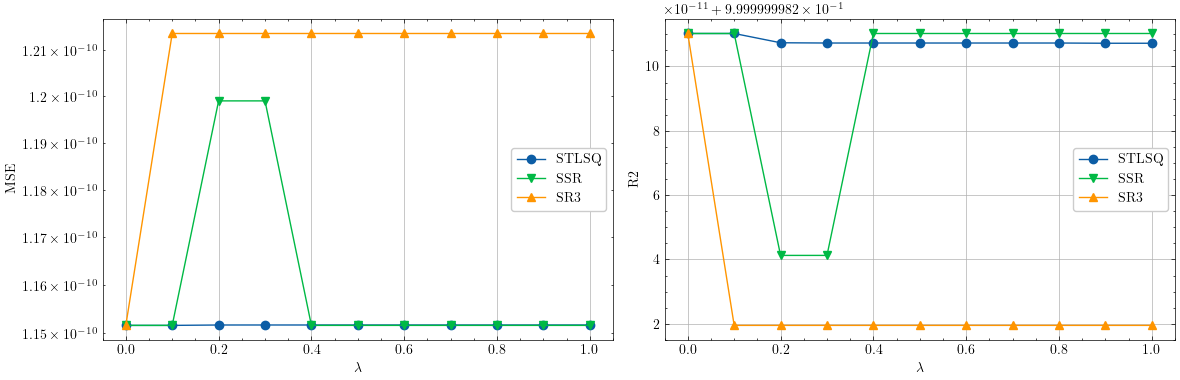

In [36]:
plt.style.use(['science'])
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.grid(True)
plt.semilogy(thr, stlsq_mse_norm, '-o', label='STLSQ')
plt.semilogy(thr, ssr_mse_norm, '-v', label='SSR')
plt.semilogy(thr, sr3_mse_norm, '-^', label='SR3')
plt.xlabel(r'$\lambda$')
plt.ylabel('MSE')
plt.legend(loc='best', frameon=True, framealpha=1.0)

plt.subplot(1, 2, 2)
plt.grid(True)
plt.plot(thr[:], stlsq_r2c_norm[:], '-o', label='STLSQ')
plt.plot(thr[:], ssr_r2c_norm[:], '-v', label='SSR')
plt.plot(thr[:], sr3_r2c_norm[:], '-^', label='SR3')
plt.xlabel(r'$\lambda$')
plt.ylabel('R2')
plt.legend(loc='best', frameon=True, framealpha=1.0)

plt.tight_layout()
plt.savefig('fig_sindy_fhn_norm.pdf',dpi=300)
plt.savefig('fig_sindy_fhn_norm.png',dpi=300)
plt.show()

In [37]:
np.savetxt("metrics_stlsq_norm.txt", np.transpose([thr,stlsq_mse_norm,stlsq_r2c_norm]))
np.savetxt("metrics_ssr_norm.txt", np.transpose([thr,ssr_mse_norm,ssr_r2c_norm]))
np.savetxt("metrics_sr3_norm.txt", np.transpose([thr,sr3_mse_norm,sr3_r2c_norm]))